# Practical Lab 1 — Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

## Object-Oriented Version

This notebook is mainly an **orchestrator and presentation layer**. Reusable application logic is imported from Python modules in `src/`:

- `database.py` → database connection helper
- `predictive_maintenance.py` → `PredictiveMaintenanceModel`
- `streaming_simulator.py` → `StreamingSimulator`

The notebook creates objects, calls reusable methods, displays results, and produces the visualizations required by the assignment.

## 1. Imports and Project Setup

In [1]:
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from sqlalchemy import text

cwd = Path.cwd()
project_root = cwd.parent if cwd.name.lower() == "notebooks" else cwd

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

training_file = project_root / "data" / "training" / "RMBR4-2_export_test.csv"
testing_folder = project_root / "data" / "testing"
results_folder = project_root / "results"

testing_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

axes = [f"Axis #{i}" for i in range(1, 9)]

print("Project root:", project_root)
print("Training file:", training_file)

Project root: d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1
Training file: d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\data\training\RMBR4-2_export_test.csv


## 2. Import Reusable Project Modules

The notebook imports reusable `.py` modules instead of defining the core predictive-maintenance logic inside the notebook.

In [2]:
from src.database import get_database_engine
from src.predictive_maintenance import PredictiveMaintenanceModel
from src.streaming_simulator import StreamingSimulator

print("Reusable project modules imported successfully.")

Reusable project modules imported successfully.


## 3. Load and Prepare Historical CSV

In [3]:
raw_df = pd.read_csv(training_file)

print("Original shape:", raw_df.shape)
display(raw_df.head())

print("\nMissing values:")
display(raw_df.isnull().sum().to_frame("Missing"))

selected_columns = ["Time"] + axes
historical_df = raw_df[selected_columns].copy()

historical_df["Time_datetime"] = pd.to_datetime(
    historical_df["Time"],
    utc=True
)

historical_df["Time_seconds"] = (
    historical_df["Time_datetime"]
    - historical_df["Time_datetime"].iloc[0]
).dt.total_seconds()

display(historical_df[["Time", "Time_seconds"] + axes].head())
print("Selected shape:", historical_df.shape)

Original shape: (39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z



Missing values:


,Missing
Trait,0
Axis #1,0
Axis #2,0
Axis #3,0
Axis #4,0
Axis #5,0
Axis #6,0
Axis #7,0
Axis #8,0
Axis #9,39672


,Time,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,2022-10-17T12:18:23.660Z,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:25.472Z,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:27.348Z,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:29.222Z,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:18:31.117Z,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Selected shape: (39672, 11)


## 4. Historical Current Visualization

In [4]:
axis_raw_dropdown = widgets.Dropdown(options=axes, value="Axis #1", description="Axis:")
raw_output = widgets.Output()

def plot_raw_axis(axis):
    with raw_output:
        clear_output(wait=True)
        plt.figure(figsize=(12, 4))
        plt.plot(historical_df["Time_seconds"], historical_df[axis])
        plt.title(f"{axis} Current Over Time")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Current")
        plt.grid(True)
        plt.show()

def update_raw_plot(change):
    plot_raw_axis(change["new"])

axis_raw_dropdown.observe(update_raw_plot, names="value")
display(axis_raw_dropdown, raw_output)
plot_raw_axis("Axis #1")

Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## 5. Neon PostgreSQL Integration

The historical CSV is stored in Neon PostgreSQL and queried back into the application. The `PredictiveMaintenanceModel` is created from the **database-loaded training data**.

In [5]:
engine = get_database_engine()

with engine.connect() as connection:
    test_value = connection.execute(text("SELECT 1")).scalar()

print("Database connection successful.")
print("Test result:", test_value)

Database connection successful.
Test result: 1


In [6]:
training_db_df = historical_df[["Time", "Time_seconds"] + axes].copy()
training_db_df.columns = [
    "time_original", "time_seconds", "axis_1", "axis_2", "axis_3",
    "axis_4", "axis_5", "axis_6", "axis_7", "axis_8"
]

training_db_df.to_sql(
    name="robot_training_data",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("Historical training data uploaded to Neon.")

Historical training data uploaded to Neon.


In [7]:
training_from_db = pd.read_sql(
    """
    SELECT *
    FROM robot_training_data
    ORDER BY time_seconds
    """,
    con=engine
)

rename_from_db = {
    "time_original": "Time",
    "time_seconds": "Time_seconds",
    **{f"axis_{i}": f"Axis #{i}" for i in range(1, 9)}
}

training_data = training_from_db.rename(columns=rename_from_db)[
    ["Time", "Time_seconds"] + axes
].copy()

print("Training data loaded from Neon:", training_data.shape)
display(training_data.head())

Training data loaded from Neon: (39672, 10)


,Time,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,2022-10-17T12:18:23.660Z,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:25.472Z,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:27.348Z,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:29.222Z,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:18:31.117Z,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Create the Predictive-Maintenance Object

`PredictiveMaintenanceModel` contains the reusable machine-learning, threshold, synthetic-data, and event-detection logic.

In [8]:
pm = PredictiveMaintenanceModel(training_data=training_data, axes=axes)
print("PredictiveMaintenanceModel object created.")

PredictiveMaintenanceModel object created.


## 7. Train Eight Linear Regression Models

In [9]:
model_summary = pm.train_models()
display(model_summary.round(6))

training_data = pm.training_data
models = pm.models

,Axis,Slope,Intercept,R2
0,Axis #1,-0.000000,0.730542,0.000002
1,Axis #2,0.000002,3.523886,0.000054
2,Axis #3,-0.000001,2.733898,0.000007
3,Axis #4,0.000000,0.604357,0.000033
4,Axis #5,0.000000,0.951103,0.000001
5,Axis #6,0.000000,0.580077,0.000037
6,Axis #7,0.000001,0.847563,0.000035
7,Axis #8,0.000000,0.098748,0.000022


### Regression Visualization

In [10]:
axis_regression_dropdown = widgets.Dropdown(options=axes, value="Axis #1", description="Axis:")
regression_output = widgets.Output()

def plot_regression(axis):
    with regression_output:
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        plt.scatter(
            training_data["Time_seconds"],
            training_data[axis],
            s=5,
            alpha=0.35,
            label="Actual"
        )
        plt.plot(
            training_data["Time_seconds"],
            training_data[f"{axis}_predicted"],
            label="Linear Regression"
        )
        plt.title(f"{axis} - Historical Data and Regression")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Current")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_regression(change):
    plot_regression(change["new"])

axis_regression_dropdown.observe(update_regression, names="value")
display(axis_regression_dropdown, regression_output)
plot_regression("Axis #1")

Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## 8. Residual Analysis and Threshold Discovery

Residual = Actual - Predicted

The reusable class discovers:

- **MinC = P95** of positive historical residuals
- **MaxC = P99** of positive historical residuals

In [11]:
thresholds_df = pm.discover_thresholds(min_quantile=0.95, max_quantile=0.99)
thresholds = pm.thresholds

display(thresholds_df.round(4))

,Axis,MinC_P95,MaxC_P99
0,Axis #1,11.3438,20.0266
1,Axis #2,24.5676,39.4509
2,Axis #3,19.6594,27.6974
3,Axis #4,7.2060,11.7136
4,Axis #5,8.5170,14.0363
5,Axis #6,9.4692,14.3679
6,Axis #7,7.2327,7.2473
7,Axis #8,3.1362,4.0778


In [12]:
axis_threshold_dropdown = widgets.Dropdown(options=axes, value="Axis #1", description="Axis:")
threshold_output = widgets.Output()

def plot_threshold_distribution(axis):
    positive_residuals = pm.get_positive_residuals(axis)
    min_c = pm.thresholds[axis]["MinC"]
    max_c = pm.thresholds[axis]["MaxC"]

    with threshold_output:
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.hist(positive_residuals, bins=50, alpha=0.7)
        plt.axvline(min_c, linestyle="--", label=f"MinC P95 = {min_c:.2f}")
        plt.axvline(max_c, linestyle="--", label=f"MaxC P99 = {max_c:.2f}")
        plt.title(f"{axis} - Positive Residual Distribution")
        plt.xlabel("Positive Residual")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_threshold_plot(change):
    plot_threshold_distribution(change["new"])

axis_threshold_dropdown.observe(update_threshold_plot, names="value")
display(axis_threshold_dropdown, threshold_output)
plot_threshold_distribution("Axis #1")

Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## 9. Persistence Threshold `T`

The class compares sustained historical exceedances for 2, 4, and 6 seconds. The selected experimental value is **T = 4 seconds**.

In [13]:
time_analysis_df = pm.analyze_persistence(
    candidate_times=(2, 4, 6),
    selected_T=4.0,
    max_gap=3.0
)

T = pm.T

display(time_analysis_df)
print(f"Selected persistence threshold T = {T} seconds")

,Axis,Total_Events,Events_>=_2s,Events_>=_4s,Events_>=_6s
0,Axis #1,333,0,0,0
1,Axis #2,561,0,0,0
2,Axis #3,575,0,0,0
3,Axis #4,470,0,0,0
4,Axis #5,424,0,0,0
5,Axis #6,405,0,0,0
6,Axis #7,288,3,0,0
7,Axis #8,297,0,0,0


Selected persistence threshold T = 4.0 seconds


### Threshold Justification

- `MinC = P95` identifies uncommon positive deviations.
- `MaxC = P99` identifies more extreme positive deviations.
- `T = 4 seconds` filters short historical spikes.

The thresholds are derived from the historical data rather than copied as fixed constants. `T = 4 seconds` is experimental for this lab, not a universal industrial safety threshold.

## 10. Generate Synthetic Testing Data

The reusable class fits `StandardScaler` using the historical data loaded from Neon, generates new standardized patterns, and transforms them back to the original current scale.

In [14]:
synthetic_test_df, metadata_comparison_df = pm.generate_synthetic_data(
    number_of_records=100,
    sampling_interval=2.0,
    random_state=42,
    noise_std=0.05
)

print("Synthetic testing data:")
display(synthetic_test_df.head())

print("Training vs Synthetic metadata:")
display(metadata_comparison_df.round(3))

Synthetic testing data:


,Time_seconds,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #1_predicted,...,Axis #4_predicted,Axis #4_residual,Axis #5_predicted,Axis #5_residual,Axis #6_predicted,Axis #6_residual,Axis #7_predicted,Axis #7_residual,Axis #8_predicted,Axis #8_residual
0,80796.968,0.464274,11.304217,1.444487,1.546660,2.298877,1.622782,0.080210,0.064965,0.721034,...,0.635787,0.910873,0.957874,1.341003,0.618411,1.004371,0.892301,-0.812091,0.105616,-0.040650
1,80798.968,0.000000,0.514250,0.000000,0.076246,0.000000,0.000000,0.017633,0.012401,0.721034,...,0.635788,-0.559542,0.957875,-0.957875,0.618412,-0.618412,0.892303,-0.874670,0.105616,-0.093215
2,80800.968,0.076887,0.272906,0.000000,0.000000,0.090094,0.000000,0.000000,0.000000,0.721034,...,0.635789,-0.635789,0.957875,-0.867781,0.618413,-0.618413,0.892304,-0.892304,0.105616,-0.105616
3,80802.968,1.907133,15.405600,1.248843,1.370651,4.910535,0.040201,8.108480,0.013076,0.721034,...,0.635789,0.734862,0.957875,3.952660,0.618414,-0.578213,0.892305,7.216175,0.105616,-0.092540
4,80804.968,0.049380,0.000000,0.000000,0.000000,0.000000,0.044204,0.000000,0.000264,0.721034,...,0.635790,-0.635790,0.957875,-0.957875,0.618415,-0.574211,0.892306,-0.892306,0.105616,-0.105352


Training vs Synthetic metadata:


,Axis,Training_Mean,Synthetic_Mean,Training_Std,Synthetic_Std
0,Axis #1,0.726,0.852,2.162,2.203
1,Axis #2,3.613,4.401,6.880,8.591
2,Axis #3,2.710,2.381,5.112,3.998
3,Axis #4,0.620,0.705,1.575,1.616
4,Axis #5,0.955,0.961,2.100,1.709
5,Axis #6,0.599,0.451,1.815,1.250
6,Axis #7,0.870,1.199,2.167,2.600
7,Axis #8,0.102,0.045,0.423,0.097


## 11. Inject Controlled Alert and Error Scenarios

Known sustained anomalies are inserted only to validate the detection logic:

- Rows 20–23 on Axis #1 → Alert-level condition
- Rows 60–63 on Axis #1 → Error-level condition

In [15]:
synthetic_test_df = pm.inject_controlled_anomalies(
    axis="Axis #1",
    alert_rows=range(20, 24),
    error_rows=range(60, 64),
    error_multiplier=1.20
)

print("Controlled Alert and Error scenarios injected.")

Controlled Alert and Error scenarios injected.


## 12. Detect and Log Sustained Events

In [16]:
all_event_log = pm.detect_events(testing_data=synthetic_test_df, T=T)

if not all_event_log.empty:
    display(all_event_log)
    event_summary = (
        all_event_log
        .groupby(["Axis", "Event"])
        .size()
        .reset_index(name="Count")
    )
    print("Event summary:")
    display(event_summary)
else:
    print("No sustained Alert or Error events were detected.")

,Axis,Event,Start_Time,Detection_Time,End_Time,Duration
0,Axis #1,ALERT,80836.968,80840.968,80842.968,6.0
1,Axis #1,ERROR,80916.968,80920.968,80922.968,6.0


Event summary:


,Axis,Event,Count
0,Axis #1,ALERT,1
1,Axis #1,ERROR,1


## 13. Final Regression Plot with Alert/Error Markers

The business logic remains in `PredictiveMaintenanceModel`; the notebook only visualizes the returned results.

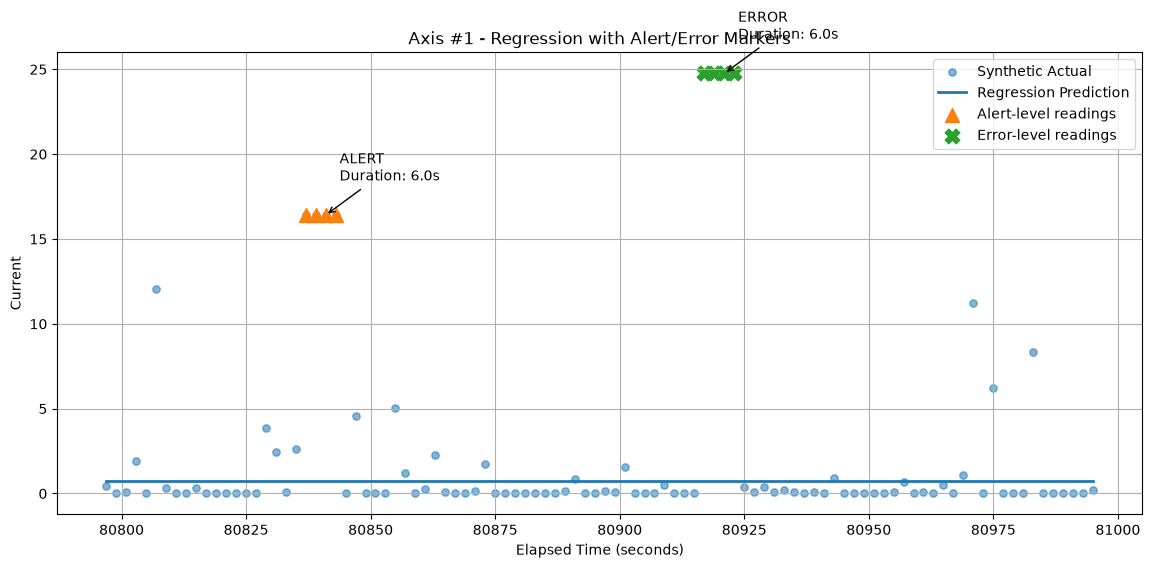

In [17]:
axis = "Axis #1"

plt.figure(figsize=(14, 6))

plt.scatter(
    synthetic_test_df["Time_seconds"],
    synthetic_test_df[axis],
    s=28,
    alpha=0.55,
    label="Synthetic Actual"
)

plt.plot(
    synthetic_test_df["Time_seconds"],
    synthetic_test_df[f"{axis}_predicted"],
    linewidth=2,
    label="Regression Prediction"
)

alert_mask = (
    synthetic_test_df[f"{axis}_residual"] >= thresholds[axis]["MinC"]
) & (
    synthetic_test_df[f"{axis}_residual"] < thresholds[axis]["MaxC"]
)

error_mask = synthetic_test_df[f"{axis}_residual"] >= thresholds[axis]["MaxC"]

plt.scatter(
    synthetic_test_df.loc[alert_mask, "Time_seconds"],
    synthetic_test_df.loc[alert_mask, axis],
    marker="^",
    s=100,
    label="Alert-level readings"
)

plt.scatter(
    synthetic_test_df.loc[error_mask, "Time_seconds"],
    synthetic_test_df.loc[error_mask, axis],
    marker="X",
    s=110,
    label="Error-level readings"
)

if not all_event_log.empty:
    axis_events = all_event_log[all_event_log["Axis"] == axis]
    for _, event in axis_events.iterrows():
        event_time = event["Detection_Time"]
        nearest_index = (
            synthetic_test_df["Time_seconds"] - event_time
        ).abs().idxmin()
        event_value = synthetic_test_df.loc[nearest_index, axis]
        plt.annotate(
            f"{event['Event']}\nDuration: {event['Duration']:.1f}s",
            xy=(event_time, event_value),
            xytext=(10, 25),
            textcoords="offset points",
            arrowprops={"arrowstyle": "->"}
        )

plt.title("Axis #1 - Regression with Alert/Error Markers")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Current")
plt.legend()
plt.grid(True)
plt.show()

## 14. Interactive Residual Detection Visualization

In [18]:
axis_detection_dropdown = widgets.Dropdown(options=axes, value="Axis #1", description="Axis:")
detection_output = widgets.Output()

def plot_detection_results(axis):
    residual_column = f"{axis}_residual"
    min_c = thresholds[axis]["MinC"]
    max_c = thresholds[axis]["MaxC"]

    with detection_output:
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        plt.plot(
            synthetic_test_df["Time_seconds"],
            synthetic_test_df[residual_column],
            marker=".",
            label="Residual"
        )
        plt.axhline(min_c, linestyle="--", label=f"MinC = {min_c:.2f}")
        plt.axhline(max_c, linestyle="--", label=f"MaxC = {max_c:.2f}")
        plt.axhline(0, linestyle=":", label="Residual = 0")
        plt.title(f"{axis} - Residual Anomaly Detection")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Residual (Actual - Predicted)")
        plt.legend()
        plt.grid(True)
        plt.show()

def update_detection_plot(change):
    plot_detection_results(change["new"])

axis_detection_dropdown.observe(update_detection_plot, names="value")
display(axis_detection_dropdown, detection_output)
plot_detection_results("Axis #1")

Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

## 15. Time-Based Synthetic Streaming into Neon PostgreSQL

This visible notebook section demonstrates the DataFrame → PostgreSQL time-based flow required by the rubric. Reusable predictive-maintenance logic remains outside the notebook.

In [19]:
create_stream_table = text(
    """
    CREATE TABLE IF NOT EXISTS robot_streaming_data (
        id BIGSERIAL PRIMARY KEY,
        time_seconds DOUBLE PRECISION NOT NULL,
        axis_1 DOUBLE PRECISION,
        axis_2 DOUBLE PRECISION,
        axis_3 DOUBLE PRECISION,
        axis_4 DOUBLE PRECISION,
        axis_5 DOUBLE PRECISION,
        axis_6 DOUBLE PRECISION,
        axis_7 DOUBLE PRECISION,
        axis_8 DOUBLE PRECISION
    )
    """
)

with engine.begin() as connection:
    connection.execute(create_stream_table)
    connection.execute(
        text("TRUNCATE TABLE robot_streaming_data RESTART IDENTITY")
    )

print("Streaming table ready.")

Streaming table ready.


In [20]:
records_to_stream = synthetic_test_df.head(5)

insert_sql = text(
    """
    INSERT INTO robot_streaming_data (
        time_seconds, axis_1, axis_2, axis_3, axis_4,
        axis_5, axis_6, axis_7, axis_8
    )
    VALUES (
        :time_seconds, :axis_1, :axis_2, :axis_3, :axis_4,
        :axis_5, :axis_6, :axis_7, :axis_8
    )
    """
)

for stream_number, (_, row) in enumerate(records_to_stream.iterrows(), start=1):
    parameters = {
        "time_seconds": float(row["Time_seconds"]),
        **{f"axis_{i}": float(row[f"Axis #{i}"]) for i in range(1, 9)}
    }

    with engine.begin() as connection:
        connection.execute(insert_sql, parameters)

    print(f"Streamed record {stream_number}/{len(records_to_stream)}")

    if stream_number < len(records_to_stream):
        time.sleep(2.0)

Streamed record 1/5
Streamed record 2/5
Streamed record 3/5
Streamed record 4/5
Streamed record 5/5


In [21]:
streamed_from_db = pd.read_sql(
    """
    SELECT *
    FROM robot_streaming_data
    ORDER BY id
    """,
    con=engine
)

print("Streaming records stored in Neon:", len(streamed_from_db))
display(streamed_from_db)

Streaming records stored in Neon: 5


,id,time_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,1,80796.968,0.464274,11.304217,1.444487,1.546660,2.298877,1.622782,0.080210,0.064965
1,2,80798.968,0.000000,0.514250,0.000000,0.076246,0.000000,0.000000,0.017633,0.012401
2,3,80800.968,0.076887,0.272906,0.000000,0.000000,0.090094,0.000000,0.000000,0.000000
3,4,80802.968,1.907133,15.405600,1.248843,1.370651,4.910535,0.040201,8.108480,0.013076
4,5,80804.968,0.049380,0.000000,0.000000,0.000000,0.000000,0.044204,0.000000,0.000264


## 16. Save Testing Data and Event Log

In [22]:
synthetic_test_path = testing_folder / "synthetic_test_data.csv"
event_log_path = results_folder / "anomaly_event_log.csv"

synthetic_test_df.to_csv(synthetic_test_path, index=False)
all_event_log.to_csv(event_log_path, index=False)

print("Synthetic testing data saved to:")
print(synthetic_test_path)
print("\nEvent log saved to:")
print(event_log_path)

Synthetic testing data saved to:
d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\data\testing\synthetic_test_data.csv

Event log saved to:
d:\Conestoga\Foundations ML Frameworks\Streming + Linear (practical lab 1)\Streaming-Data_W_Linear-Regression_Practical-Lab1\results\anomaly_event_log.csv


## 17. Object-Oriented Real-Time Prediction Simulation

`StreamingSimulator` is a second reusable class imported from `src/`. It processes incoming synthetic readings sequentially using the models and thresholds produced by `PredictiveMaintenanceModel`.

In [23]:
ss = StreamingSimulator(
    data=synthetic_test_df,
    models=pm.models,
    thresholds=pm.thresholds,
    T=pm.T,
    interval=2.0
)

print("StreamingSimulator object created.")

StreamingSimulator object created.


In [24]:
# Demonstrate the controlled Alert section.
ss.reset()
ss.current_index = 18
ss.stream(number_of_records=8)


Record 19 | Time: 80832.97
Axis #1 | Actual: 0.089 | Predicted: 0.721 | Residual: -0.632 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 11.573 | Predicted: 3.701 | Residual: 7.872 | Duration: 0.0s | Status: NORMAL
Axis #3 | Actual: 6.306 | Predicted: 2.687 | Residual: 3.619 | Duration: 0.0s | Status: NORMAL
Axis #4 | Actual: 2.252 | Predicted: 0.636 | Residual: 1.617 | Duration: 0.0s | Status: NORMAL
Axis #5 | Actual: 1.513 | Predicted: 0.958 | Residual: 0.555 | Duration: 0.0s | Status: NORMAL
Axis #6 | Actual: 1.461 | Predicted: 0.618 | Residual: 0.843 | Duration: 0.0s | Status: NORMAL
Axis #7 | Actual: 0.417 | Predicted: 0.892 | Residual: -0.476 | Duration: 0.0s | Status: NORMAL
Axis #8 | Actual: 0.114 | Predicted: 0.106 | Residual: 0.009 | Duration: 0.0s | Status: NORMAL

Record 20 | Time: 80834.97
Axis #1 | Actual: 2.642 | Predicted: 0.721 | Residual: 1.921 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 19.936 | Predicted: 3.701 | Residual: 16.235 | Duration: 0.0s | Stat

In [25]:
# Demonstrate the controlled Error section.
ss.reset()
ss.current_index = 58
ss.stream(number_of_records=8)


Record 59 | Time: 80912.97
Axis #1 | Actual: 0.011 | Predicted: 0.721 | Residual: -0.710 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.000 | Predicted: 3.701 | Residual: -3.701 | Duration: 0.0s | Status: NORMAL
Axis #3 | Actual: 0.202 | Predicted: 2.687 | Residual: -2.485 | Duration: 0.0s | Status: NORMAL
Axis #4 | Actual: 0.027 | Predicted: 0.636 | Residual: -0.609 | Duration: 0.0s | Status: NORMAL
Axis #5 | Actual: 0.070 | Predicted: 0.958 | Residual: -0.888 | Duration: 0.0s | Status: NORMAL
Axis #6 | Actual: 0.000 | Predicted: 0.618 | Residual: -0.618 | Duration: 0.0s | Status: NORMAL
Axis #7 | Actual: 0.097 | Predicted: 0.892 | Residual: -0.795 | Duration: 0.0s | Status: NORMAL
Axis #8 | Actual: 0.034 | Predicted: 0.106 | Residual: -0.071 | Duration: 0.0s | Status: NORMAL

Record 60 | Time: 80914.97
Axis #1 | Actual: 0.000 | Predicted: 0.721 | Residual: -0.721 | Duration: 0.0s | Status: NORMAL
Axis #2 | Actual: 0.000 | Predicted: 3.701 | Residual: -3.701 | Duration: 0.0s |

## Conclusion

This project uses an Object-Oriented architecture for the reusable predictive-maintenance workflow.

### Reusable Python modules

- `src.database` provides the database connection helper.
- `PredictiveMaintenanceModel` manages regression training, residuals, thresholds, persistence analysis, synthetic-data generation, controlled anomaly injection, and event detection.
- `StreamingSimulator` manages sequential real-time prediction and Alert/Error status tracking.

### Notebook responsibility

The notebook acts mainly as an orchestrator and presentation layer. It creates objects, calls reusable methods, displays results, and produces the required plots. This separation makes the code easier to maintain, reuse, test, and extend.